# Set sub-grid widths for selected channels

In [1]:
import os
import sys
sys.path.insert(0,os.path.abspath('src'))
from datetime import date

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import xarray as xr

import os
from datetime import date

import matplotlib.pyplot as plt
from topo_edit_util import inspect_topo, create_soc_topo_table

## Get input topography data set

In [3]:
grid = 'tx1_12v1'
topo = 'GEBCO_2025'
nsub = 'sub25'
topo_src = 'GEBCO_2025'
edit = 'edit1'
case = 'SmL1.0_C1.0'
create_date = 'Dec2025'
depth_var_in = 'D_interp'

path_root = '/glade/derecho/scratch/gmarques/'

In [4]:
path_in = path_root + grid + '_' + topo_src + '_' + create_date + '/'
file_in = 'topo.' + nsub + '.' + grid + '.' + topo_src + '.' + edit + '.' + case + '.nc'
print(path_in+file_in)
dss = xr.open_dataset(path_in+file_in)

/glade/derecho/scratch/bryan/tx1_12v1_GEBCO_2025_Dec2025/topo.sub25.tx1_12v1.GEBCO_2025.edit1.SmL1.0_C1.0.nc


In [5]:
dss

<xarray.Dataset>
Dimensions:     (lonh: 4320, lath: 3240, lonq: 4321, latq: 3241)
Coordinates:
  * lonh        (lonh) float64 -287.0 -286.9 -286.8 -286.7 ... 72.79 72.88 72.96
  * lath        (lath) float64 -80.06 -80.04 -80.03 -80.01 ... 89.92 89.95 89.98
  * lonq        (lonq) float64 -287.0 -286.9 -286.8 -286.8 ... 72.83 72.92 73.0
  * latq        (latq) float64 -80.06 -80.05 -80.04 -80.02 ... 89.93 89.96 89.98
Data variables: (12/15)
    geolon      (lath, lonh) float64 ...
    geolat      (lath, lonh) float64 ...
    geolonb     (latq, lonq) float64 ...
    geolatb     (latq, lonq) float64 ...
    z           (lath, lonh) float32 ...
    ocn_frac    (lath, lonh) float32 ...
    ...          ...
    D2_mean     (lath, lonh) float32 ...
    D_min       (lath, lonh) float32 ...
    D_max       (lath, lonh) float32 ...
    hand_edits  (lath, lonh) int32 ...
    orig_mask   (lath, lonh) int32 ...
    D_interp    (lath, lonh) float32 ...
Attributes:
    Description:             Ocean Topography Statistics on MOM6 Grid
    Creator:                 Frank Bryan
    Created:                 20251217
    Generating Code:         create_model_topo.f90
    Model Grid Version:      tx1_12v1
    Source Topography Data:  /glade/work/bryan/Observations/Topography/Wallcr...
    Edit History:            Hand Edit + Lake Fill 12/19/2025

In [6]:
soc_table = create_soc_topo_table()

## Set up output files

In [7]:
today = date.today()

path_out = path_in
file_out_chan = 'Channels_' + grid + '_' + topo_src + '_' + today.strftime("%m.%d.%Y") + '.txt'
print('channel width file : ',file_out_chan)

fmt_out = "{0:s}, {1:8.2f}, {2:8.2f}, {3:8.2f}, {4:8.2f}, {5:10.1f} ! {6:s}\n"

channel width file :  Channels_tx1_12v1_GEBCO_2025_12.19.2025.txt


## Selected Straits

### Strait of Gibralter

{'lat': 35.92, 'lon': -5.75, 'depth': 284.0, 'width': 10.0}


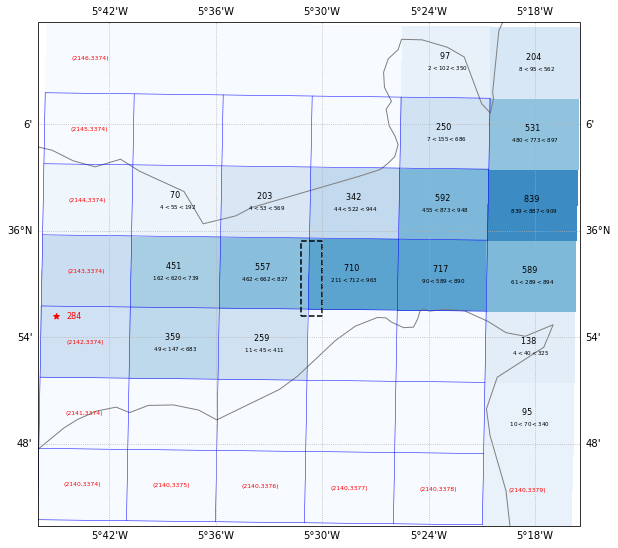

In [8]:
place = 'St. of Gibralter'
print(soc_table[place])
lon_beg = -5.75
lon_end = -5.25
lat_beg = 35.75
lat_end = 36.25
zmax = 1300.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

lon1 = -5.52
lat1 = 35.92
lon2 = -5.50
lat2 = 35.99
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')


In [9]:
width = 10.0e3
print('width = ',width)

with open(path_out+file_out_chan,'w') as f:
    line = fmt_out.format("U_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  10000.0


{'lat': 35.92, 'lon': -5.75, 'depth': 284.0, 'width': 10.0}


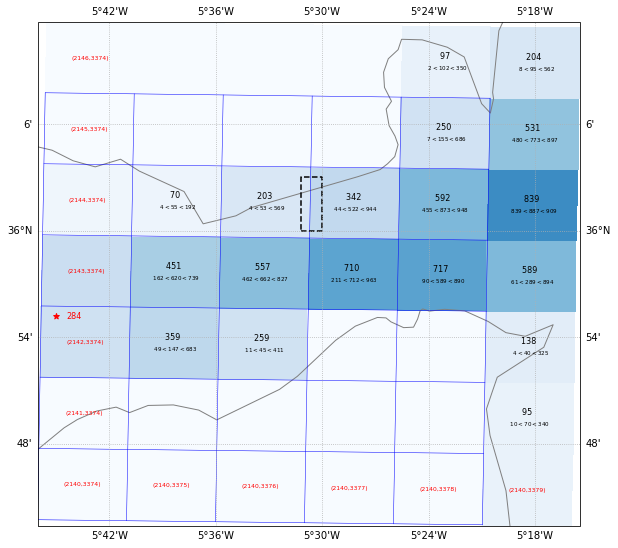

In [10]:
place = 'St. of Gibralter'
print(soc_table[place])
lon_beg = -5.75
lon_end = -5.25
lat_beg = 35.75
lat_end = 36.25
zmax = 1300.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

lon1 = -5.52
lat1 = 36.
lon2 = -5.50
lat2 = 36.05
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')


In [11]:
width = 2.0e3
print('width = ',width)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("U_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  2000.0


### Bosphorus

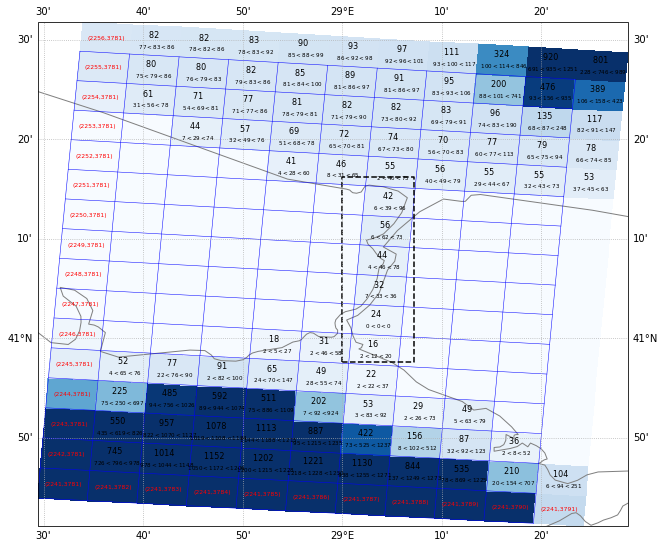

In [12]:
## Black Sea / Bosphorus
place = 'Bosphorus St.'
lon_beg = 28.5
lon_end = 29.5
lat_beg = 40.75
lat_end = 41.5
zmax = 500.


ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

lon1 = 29.0
lat1 = 40.96
lon2 = 29.12
lat2 = 41.27
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')


In [13]:
width = 5.0e3
print('width = ',width)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("V_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  5000.0


### Dardanelles

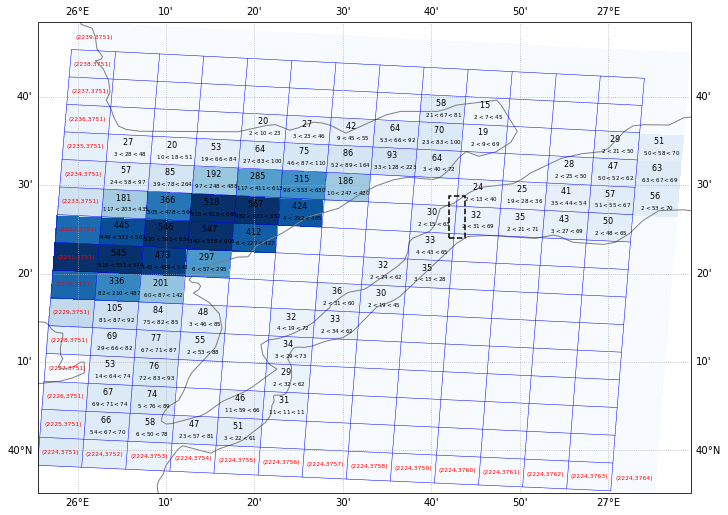

In [14]:
place = 'Dardanelles'
lon_beg = 26.
lon_end = 27.2
lat_beg = 40
lat_end = 40.75
zmax = 500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

lon1 = 26.7
lat1 = 40.40
lon2 = 26.73
lat2 = 40.48
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')


In [15]:
width = 5.0e3
print('width = ',width)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("U_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  5000.0
